In [7]:
import numpy as np
import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt

from utils import ff_nn
from utils_hyperelasticity import NODE, NODE_model_iso, ThreeDElasticity, split_c_s_params_iso, merge_c_s_params_iso
from jax.flatten_util import ravel_pytree
from jax_fem.generate_mesh import get_meshio_cell_type, Mesh, rectangle_mesh
from fem import plotmesh

### 1. Save the strain field contour

In [8]:
with open('data/manu/stiff2_hetero_disp.npy', 'rb') as f:
    x,y,ux_hist,uy_hist = pickle.load(f)
with open('data/manu/temp.npy', 'rb') as f:
    E_hist_dic = pickle.load(f)

x1 = 4
x2 = 42
y1 = 2
y2 = 40
out = []
for aux in E_hist_dic:
    out.append(aux.transpose([2,0,1]).reshape([42,43,2,2]).transpose([1,0,2,3])[x1:x2,y1:y2,:,:].reshape([-1,2,2])) # I know. wtf?
E_hist_dic = np.array(out)
elem_X = np.stack([x.flatten(),y.flatten()]).T

i1 = 10
i2 = None
skip = 30
ux_hist = jnp.array(ux_hist[i1:i2:skip])
uy_hist = jnp.array(uy_hist[i1:i2:skip])

E_hist_dic = E_hist_dic[i1:i2:skip]

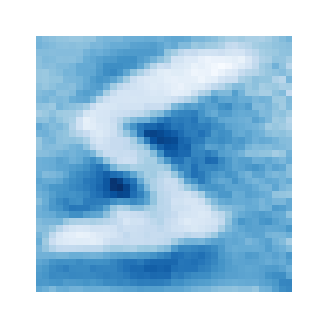

In [56]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)
Nx, Ny = x.shape[0], x.shape[1]
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])


fig, ax = plt.subplots(figsize=(5,4))
evals, efuns = jnp.linalg.eigh(E_hist_dic[-1])
E_11, E_22 = evals.T
mps = np.maximum(E_11, E_22)

plotmesh(mesh.cells, mesh.points, mps, title=None, ax=ax, ec='None', cbar=False);  
fig.savefig('figs/fig_summary/strainfield.pdf', bbox_inches='tight')

### 2. Save the material property contour

In [18]:
with open('params/AM_stiff2_post.npy', 'rb') as f:
    mesh, elem_X, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean = pickle.load(f)
common_params, sample_params = split_c_s_params_iso(node_params)
_, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_iso(merge_c_s_params_iso(common_params, unravel(params)))

In [19]:
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X = mesh2.points[mesh2.cells].mean(axis=1)

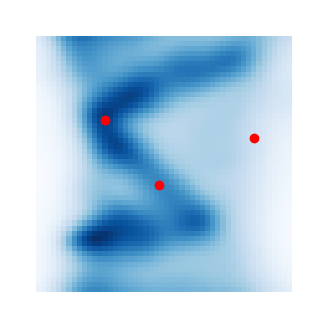

In [37]:
# Stiffness across the domain
fig, ax = plt.subplots(figsize=(5,4))

F = np.array([[F_xx_mean[-1], F_xy_mean[-1]],
              [F_yx_mean[-1], F_yy_mean[-1]]])
ugrad = F - np.eye(2)

params_pr = ff_nn(elem_X, Lambda_params)
c_elem_pr = []
for params_pr_i in params_pr:
    c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title=None, ax=ax, ec='None', cbar=False); 

p1 = np.array([[0.27, 0.67]])
p2 = np.array([[0.85, 0.60]])
p3 = np.array([[0.48, 0.42]])
ax.plot(p1[:,0], p1[:,1], 'ro')
ax.plot(p2[:,0], p2[:,1], 'ro')
ax.plot(p3[:,0], p3[:,1], 'ro')
fig.savefig('figs/fig_summary/materialfield.pdf', bbox_inches='tight')

### 3. Plot stress vs strain at the 3 points

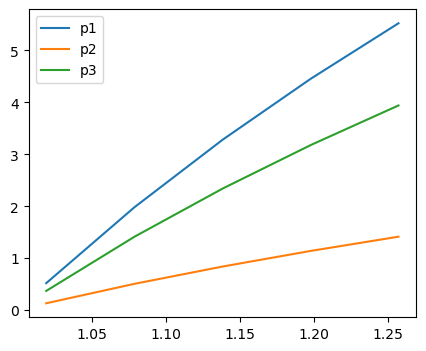

In [47]:
p1_data = []
p2_data = []
p3_data = []
for F_xx, F_xy, F_yx, F_yy in zip(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_p1 = ff_nn(p1, Lambda_params)[0]
    p1_data.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_p1, 2)[1,1])

    params_p2 = ff_nn(p2, Lambda_params)[0]
    p2_data.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_p2, 2)[1,1])

    params_p3 = ff_nn(p3, Lambda_params)[0]
    p3_data.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_p3, 2)[1,1])


fig, ax = plt.subplots(figsize=(5,4))
ax.plot(F_yy_mean, p1_data, label='p1')
ax.plot(F_yy_mean, p2_data, label='p2')
ax.plot(F_yy_mean, p3_data, label='p3')
ax.legend()

np.savetxt('figs/fig_summary/threepoints.csv', np.array([F_yy_mean, p1_data, p2_data, p3_data]).T, header='x p1 p2 p3', comments='')